# Ejemplo de aplicación de índices

Al área urbana de Gran Valparaíso

## Imports

In [2]:
%reload_ext autoreload
%autoreload 2

In [ ]:
import geopandas as gpd

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors

import sys
import os
import datetime
from pathlib import Path
from dotenv import load_dotenv

In [15]:
sys.path.insert(0, os.path.abspath('..'))

from xmin.dataset import extract_osm_subset
from xmin.amenities import Amenity, osm_amenity
from xmin.origins import Origins
from xmin.travel_time import calculate_travel_time_matrices
from xmin.indices import BinaryIndex, TwoStepFca, calculate_weighted_index

In [17]:
load_dotenv(override=True)
RAW_DATA_PATH = Path(os.getenv("RAW_DATA_PATH"))  # datos no procesados
PRE_DATA_PATH = Path(os.getenv("PRE_DATA_PATH"))  # datos preprocesados

## Datos a utilizar

- [Cartografía del Censo 2024](https://censo2024.ine.gob.cl/resultados/)
- [Dataset de OSM para Chile](https://download.geofabrik.de/south-america/chile.html)
- [Indicadores de Calidad de Plazas y Parques Urbanos (2019)](https://arcg.is/1LTLCf)
- [Establecimientos de salud de Chile (Diciembre 2025)](https://geoportal.cl/geoportal/catalog/36779/Establecimientos%20de%20salud%20de%20Chile%20Diciembre%202025)

In [39]:
CENSO_PATH = RAW_DATA_PATH / "censo" / "Cartografia.gpkg"
OSM_CHILE_PATH = RAW_DATA_PATH / "osm" / "Chile.osm.pbf"
AMENITY_VERDES_PATH = RAW_DATA_PATH / "amenities" / "parques" / "CALIDAD_pzpq_2019_G1G2.shp"
AMENITY_SALUD_PATH = RAW_DATA_PATH / "amenities" / "salud"

OSM_VALPARAISO_PATH = PRE_DATA_PATH / "osm" / "Valparaiso.osm.pbf"

## Límites urbanos y orígenes

In [40]:
# carga de datos y cambio de sistema de coordenadas
limites_urbanos_full = gpd.read_file(
    CENSO_PATH,
    layer="Limite_Urbano_CPV24"
)
limites_urbanos = limites_urbanos_full.to_crs(4326)

# filtramos solo las áreas de interés
limites_urbanos = limites_urbanos[
    (limites_urbanos["LOCALIDAD"] == "GRAN VALPARAÍSO")
]

# obtenemos envoltura convexa para extraer POIs y red vial
limites_envoltura = limites_urbanos.union_all().convex_hull

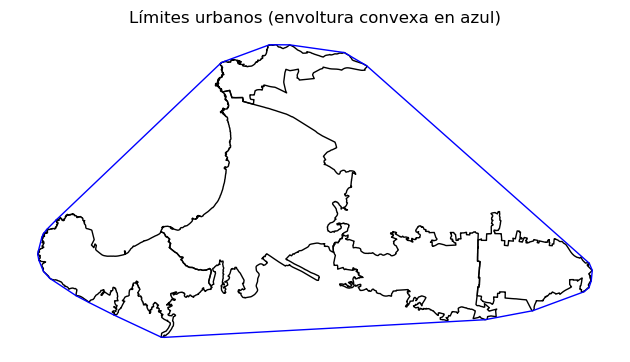

In [41]:
ax = limites_urbanos.plot(facecolor="none", edgecolor="black")
gpd.GeoSeries([limites_envoltura]).plot(ax=ax, facecolor="none", edgecolor="blue")
ax.set_axis_off()
plt.title("Límites urbanos (envoltura convexa en azul)")
plt.tight_layout()

In [42]:
manzanas = gpd.read_file(
    CENSO_PATH,
    layer="Manzanas_CPV24",
    mask=limites_urbanos.union_all(),
    use_arrow=True
).to_crs(4326).rename(columns={"n_per": "population"})

In [43]:
origins = Origins(
    bounds=limites_urbanos,
    h3_level=9,
    population_gdf=manzanas
)
len(origins.h3_grid)

1796

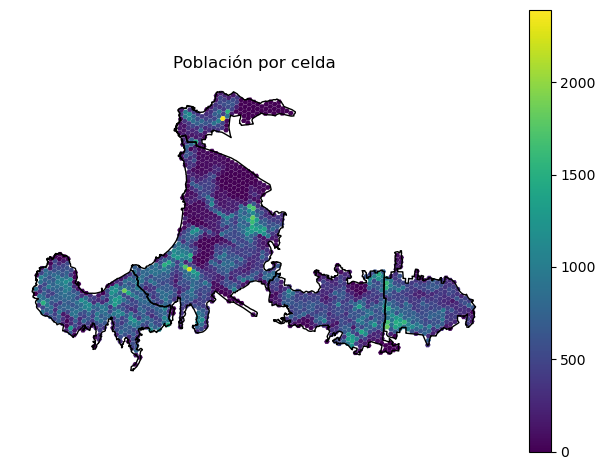

In [44]:
ax = origins.h3_grid.plot("population", legend=True)
limites_urbanos.plot(ax=ax, facecolor="none", edgecolor="black")
ax.set_axis_off()
plt.title("Población por celda")
plt.tight_layout()

## OSM y Amenities

In [45]:
if not OSM_VALPARAISO_PATH.exists():
    extract_osm_subset(
        OSM_CHILE_PATH,
        OSM_VALPARAISO_PATH,
        bounds=limites_envoltura
    )

In [46]:
farmacias = osm_amenity(
    name="farmacias",
    osm_path=OSM_VALPARAISO_PATH,
    osm_filter={"amenity": ["pharmacy"]},
)

In [47]:
supermercados = osm_amenity(
    name="supermercados",
    osm_path=OSM_VALPARAISO_PATH,
    osm_filter={"shop": ["supermarket"]},
)

In [48]:
verdes_gdf = gpd.read_file(AMENITY_VERDES_PATH)

verdes_gdf = verdes_gdf.rename(columns={"TARGET_FID": "id"})
verdes_gdf = verdes_gdf[verdes_gdf.within(limites_envoltura)]

In [49]:
plazas = Amenity("plazas", verdes_gdf[verdes_gdf["TIPO_EP"]=="PLAZA"])
parques = Amenity("parques", verdes_gdf[verdes_gdf["TIPO_EP"]=="PARQUE"])

/mnt/c/Users/clau/ie/u/memoria/x-minute-chile/xmin/amenities.py:49: UserWarning: GeoDataFrame contiene geometrías que no son puntos; estas serán convertidas a puntos mediante sus centroides.
  warnings.warn(
/mnt/c/Users/clau/ie/u/memoria/x-minute-chile/xmin/amenities.py:49: UserWarning: GeoDataFrame contiene geometrías que no son puntos; estas serán convertidas a puntos mediante sus centroides.
  warnings.warn(


In [50]:
salud_gdf = gpd.read_file(AMENITY_SALUD_PATH)

salud_gdf = salud_gdf.rename(columns={"ID_ORIG": "id"})
salud_gdf = salud_gdf[salud_gdf.within(limites_envoltura)]

In [51]:
salud = Amenity("salud", salud_gdf[salud_gdf["NIVEL"]=="Primario"])

## Cálculo de tiempos de viaje e índices de accesibilidad

Se calcula la matriz de tiempo de viaje para cada necesidad.

In [52]:
matrices = calculate_travel_time_matrices(
    origins=origins,
    amenities=[farmacias, supermercados, salud, plazas, parques],
    gtfs_paths=[],
    osm_path=OSM_VALPARAISO_PATH,
    snap_to_network=True,
    max_time=datetime.timedelta(minutes=30),
    transport_modes=["WALK"],
)

100%|██████████| 1796/1796 [00:18<00:00, 97.98it/s] 


In [58]:
ttm_farmacias = matrices[farmacias]
ttm_farmacias[ttm_farmacias["travel_time"].notna()].sample(10)

,from_id,to_id,travel_time
1771986,89b2c4091b3ffff,1.188734e+10,27.0
2100456,89b2c409ecbffff,3.393341e+09,20.0
1347612,89b2c40f1d7ffff,9.256473e+09,29.0
1482323,89b2c40910bffff,5.258266e+09,14.0
1414952,89b2c409ec7ffff,5.316796e+09,27.0
295555,89b2c4092b7ffff,3.393342e+09,2.0
1364046,89b2c40e31bffff,1.734621e+09,29.0
1295476,89b2c418abbffff,3.477712e+08,11.0
1308584,89b2c408467ffff,5.965301e+09,29.0
957600,89b2c41990fffff,1.267093e+10,6.0


Se calcula el índice, ponderando los índices de las distintas necesidades.

In [59]:
weights = {
    farmacias: 1,
    supermercados: 1,
    plazas: 0.5,
    parques: 0.5,
    salud: 1
}

index_hard = TwoStepFca(15, 3_000)
indices = {
    farmacias: index_hard,
    supermercados: index_hard,
    plazas: index_hard,
    parques: TwoStepFca(20, 10_000),
    salud: TwoStepFca(30, 10_000)
}

In [60]:
accessibility = calculate_weighted_index(
    origins,
    matrices,
    indices,
    weights
)

## Visualizaciones

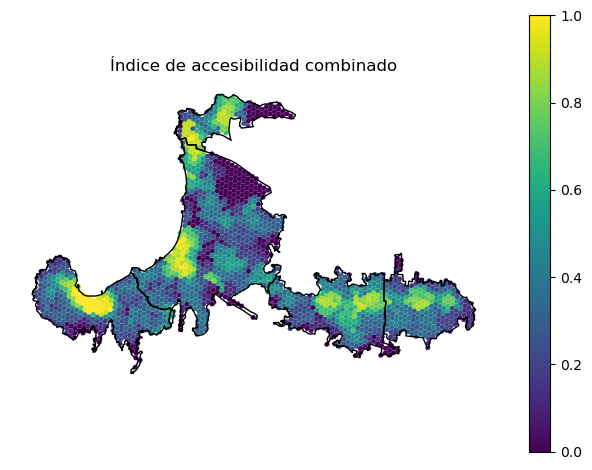

In [61]:
ax = accessibility.plot("total", legend=True)
limites_urbanos.plot(ax=ax, facecolor="none", edgecolor="black")
ax.set_axis_off()
plt.title("Índice de accesibilidad combinado")
plt.tight_layout()

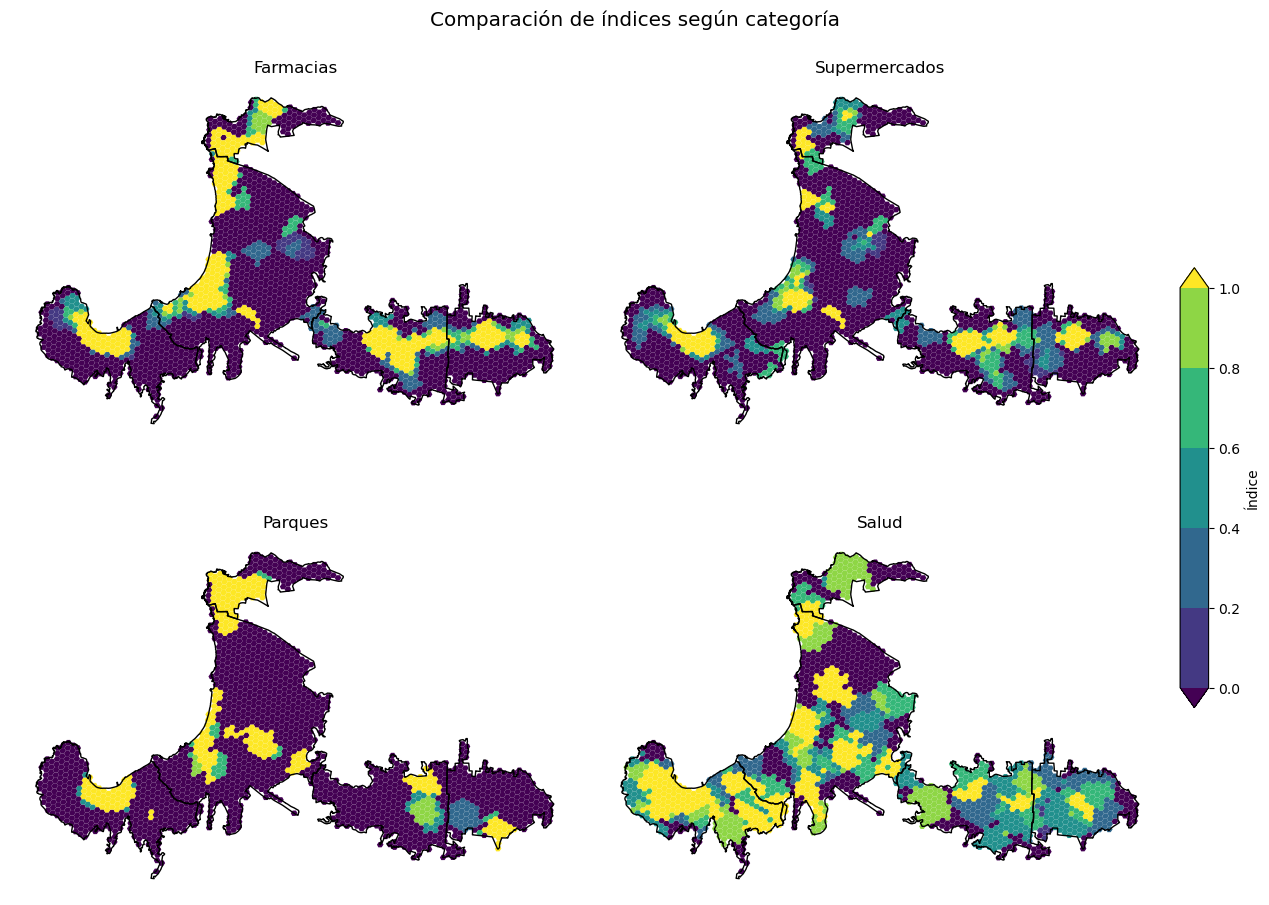

In [68]:
fig = plt.figure(figsize=(2*6.4, 2*4.8))
gs = GridSpec(4, 3, figure=fig, width_ratios=[100, 100, 5])
ax_farmacias = fig.add_subplot(gs[0:2, 0])
ax_supermercados = fig.add_subplot(gs[0:2, 1])
ax_parques = fig.add_subplot(gs[2:4, 0])
ax_salud = fig.add_subplot(gs[2:4, 1])
ax_cb = fig.add_subplot(gs[1:3, 2])

norm = mcolors.BoundaryNorm([1e-10, 0.2, 0.4, 0.6, 0.8, 1.0], ncolors=256, extend="both")

for ax, category in zip(
    (ax_farmacias, ax_supermercados, ax_parques, ax_salud),
    ("farmacias", "supermercados", "parques", "salud")
):
    ax.set_axis_off()
    accessibility.plot(
        category,
        legend=False,
        norm=norm,
        ax=ax
    )
    limites_urbanos.plot(ax=ax, facecolor="none", edgecolor="black")
    ax.set_title(category.capitalize())
    
cbar = plt.cm.ScalarMappable(norm=norm, cmap="viridis")
axCbar = fig.colorbar(cbar, cax=ax_cb)
axCbar.set_label(f"Índice")

fig.suptitle("Comparación de índices según categoría", fontsize="x-large")

plt.tight_layout()